In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(
    r"C:\Users\LENOVO\Downloads\ai4i+2020+predictive+maintenance+dataset\ai4i2020.csv"
)
df.head(), df.shape

(   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
 0    1     M14860    M                298.1                    308.6   
 1    2     L47181    L                298.2                    308.7   
 2    3     L47182    L                298.1                    308.5   
 3    4     L47183    L                298.2                    308.6   
 4    5     L47184    L                298.2                    308.7   
 
    Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
 0                    1551         42.8                0                0    0   
 1                    1408         46.3                3                0    0   
 2                    1498         49.4                5                0    0   
 3                    1433         39.5                7                0    0   
 4                    1408         40.0                9                0    0   
 
    HDF  PWF  OSF  RNF  
 0    0    0    0    0  
 1    0    0    

In [7]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [4]:
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]
df[features].head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,298.1,308.6,1551,42.8,0
1,298.2,308.7,1408,46.3,3
2,298.1,308.5,1498,49.4,5
3,298.2,308.6,1433,39.5,7
4,298.2,308.7,1408,40.0,9


In [11]:
df = df[features + ['Machine failure']]
df

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,298.1,308.6,1551,42.8,0,0
1,298.2,308.7,1408,46.3,3,0
2,298.1,308.5,1498,49.4,5,0
3,298.2,308.6,1433,39.5,7,0
4,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...
9995,298.8,308.4,1604,29.5,14,0
9996,298.9,308.4,1632,31.8,17,0
9997,299.0,308.6,1645,33.4,22,0
9998,299.0,308.7,1408,48.5,25,0


In [17]:
df.isna().sum()


Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
High_Risk_Flag             0
dtype: int64

In [12]:
failure_rate = (
    df['Machine failure'].value_counts(normalize=True) * 100
)

failure_rate

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [13]:
failure_comparison = df.groupby('Machine failure').mean()

failure_comparison


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


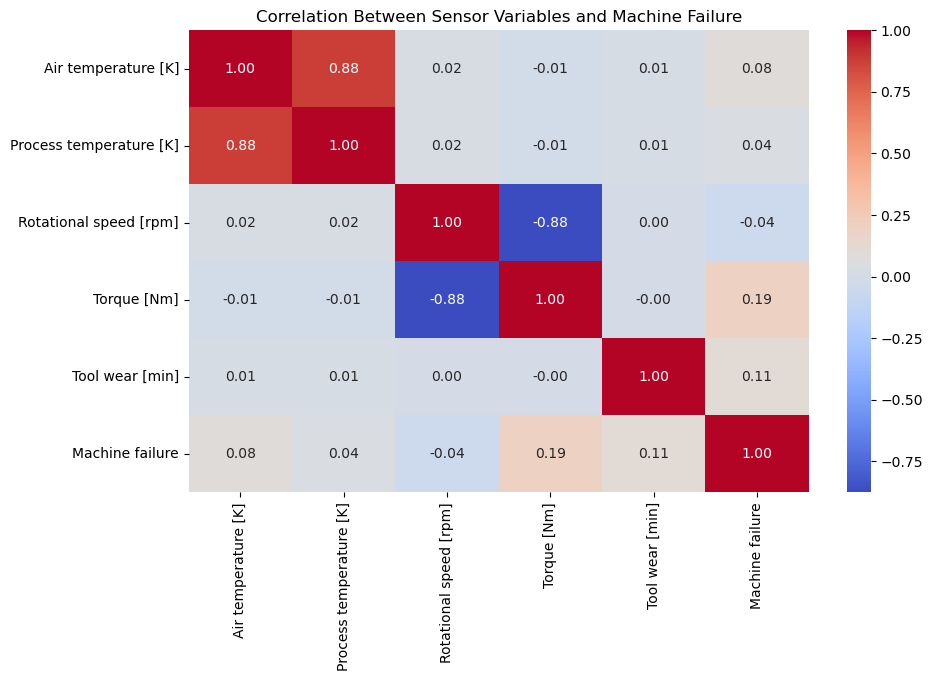

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Between Sensor Variables and Machine Failure")
plt.show()

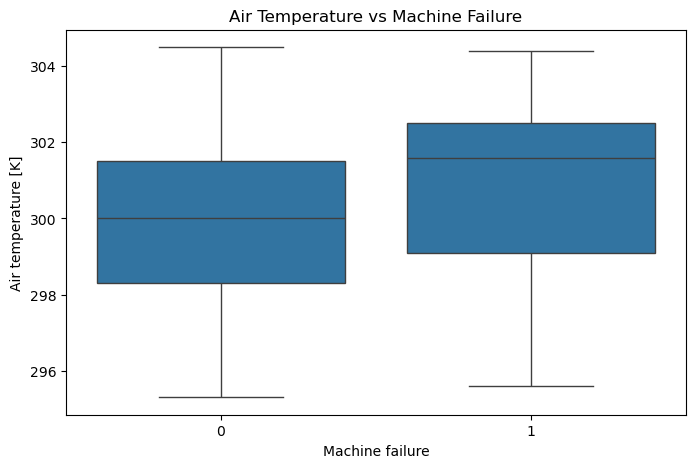

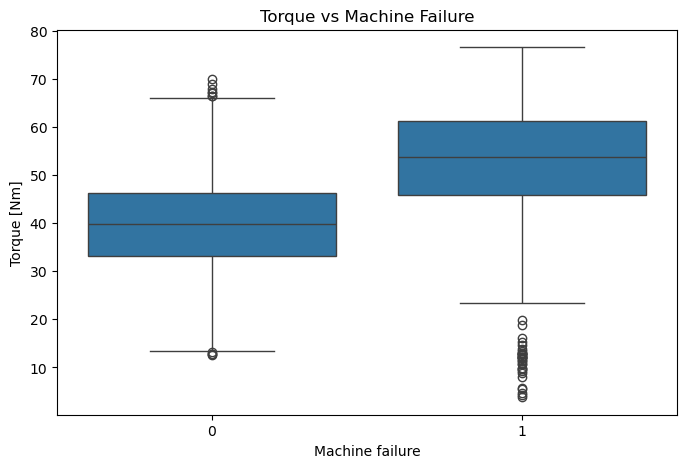

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Machine failure',
    y='Air temperature [K]',
    data=df
)
plt.title("Air Temperature vs Machine Failure")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(
    x='Machine failure',
    y='Torque [Nm]',
    data=df
)
plt.title("Torque vs Machine Failure")
plt.show()

In [5]:
risk_thresholds = df[features].quantile(0.90)

risk_thresholds

df['High_Risk_Flag'] = (
    (df['Air temperature [K]'] > risk_thresholds['Air temperature [K]']) |
    (df['Torque [Nm]'] > risk_thresholds['Torque [Nm]']) |
    (df['Tool wear [min]'] > risk_thresholds['Tool wear [min]'])
)

df[['High_Risk_Flag', 'Machine failure']].value_counts()

High_Risk_Flag  Machine failure
False           0                  7290
True            0                  2371
                1                   274
False           1                    65
Name: count, dtype: int64